# Network Spread Information Experiments

This notebook explores the dynamics of misinformation spread on networks using a multi-agent reinforcement learning approach. Two agents compete for control of the network:
- **Agent A (Spreader)**: Aims to spread information through the network
- **Agent B (Healer)**: Aims to contain and reduce the spread

We'll begin with some visualizations of random agent behavior, then train the agents using PPO, and finally analyze the results.

## Install Required Dependencies
First, we'll install the necessary packages for our experiments.

In [ ]:
# Install required packages
%pip install -q "ray[rllib]==2.4.0" "prettyprinter" "gymnasium>=0.28.1" "networkx>=2.8.4" "numpy>=1.22.4" "pandas>=1.5.3" "matplotlib>=3.5.1" "seaborn>=0.12.0" "tqdm>=4.64.0" "torch>=1.13.1"

# Verify installations
import ray
import gymnasium as gym
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import torch

print(f"Ray version: {ray.__version__}")
print(f"Gymnasium version: {gym.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Make sure the custom modules are in the Python path
import sys
import os

# Add the modules directory to the path if not already there
modules_dir = os.path.join(os.getcwd(), "modules")
if modules_dir not in sys.path:
    sys.path.append(modules_dir)
    print(f"Added {modules_dir} to Python path")

Ray version: 2.10.0
Gymnasium version: 0.28.1
NetworkX version: 3.1
NumPy version: 1.24.4
Pandas version: 2.0.3
PyTorch version: 2.4.1
Added /Users/UM/Documents/UM25/Complex/RL Project/modules/modules to Python path


In [3]:
import warnings
import re

# Suppress Ray deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, 
                        module=r'ray\..*')
warnings.filterwarnings("ignore", message=".*_get_slice_indices.*")

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [49]:
# Import necessary libraries
import os
import sys
import ray
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import random
from prettyprinter import pprint as prettyprint
from tqdm.notebook import tqdm
from IPython.display import clear_output, display
from ray.rllib.algorithms import Algorithm
from ray.rllib.algorithms.ppo import PPOConfig
from ray.tune.registry import register_env
from ray.rllib.policy.policy import PolicySpec

# Make sure the custom modules are in the Python path
modules_dir = os.path.join(os.getcwd(), "modules")
if modules_dir not in sys.path:
    sys.path.append(modules_dir)
    print(f"Added {modules_dir} to Python path")

# Import custom modules - use direct imports without the 'modules.' prefix
from NetworkEnvironmentConfig import NetworkEnvironmentConfig
from InfectionNetwork import NetworkGenerator, NetworkType, InformationNetwork, NodeState
from Features import FeatureRegistry, NodeFeatures
from InfectionSpreadEnv import env_creator, MultiAgentNetworkEnv, InfoSpreadCallbacks

# Set up seaborn style
sns.set(style="whitegrid", context="notebook", palette="colorblind")

# Set up directories for storing results
RESULTS_DIR = os.path.join(os.getcwd(), "experiment_results")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

# Create directories if they don't exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

## 1. Visualizing a Random Policy Episode

First, let's create a simple configuration and visualize how random agents behave in our environment.

In [ ]:
# Create a configuration for visualization
# This is also our viral config later on 
vis_config = NetworkEnvironmentConfig(
    desc="Viral (scale free)",
    network_type=NetworkType.SCALE_FREE,
    nx_n=100,
    nx_m=4,  # Higher connectivity
    num_nodes=100,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.1,
    infection_probability=0.9,  # Very high infection rate
    recovery_probability=0.5,   # High recovery rate
    max_steps=120,
    max_action_radius=1
)

# Create the environment
env = MultiAgentNetworkEnv(vis_config)

In [6]:
def visualize_network_state(network, step, infection_rate, agent_a_action=None, agent_b_action=None):
    """Visualize the current state of the network with agent actions."""
    plt.figure(figsize=(12, 10))
    
    # Create a color map based on node states
    colors = {
        NodeState.SUSCEPTIBLE: 'skyblue',
        NodeState.INFECTED: 'crimson',
    }
    
    # Get node colors based on state
    node_colors = [colors[network.nodes[n]['state']] for n in network.nodes()]
    
    # Get node sizes (highlight agent actions)
    node_sizes = []
    for n in network.nodes():
        size = 300  # Default size
        if agent_a_action is not None and n == agent_a_action:
            size = 800  # Larger for Agent A's target
        if agent_b_action is not None and n == agent_b_action['node_id']:
            size = 800  # Larger for Agent B's target
        node_sizes.append(size)
    
    # Get edge weights for visualization
    edge_weights = [network[u][v]['weight'] * 2 for u, v in network.edges()]
    
    # Create the layout (consistent across steps)
    pos = nx.spring_layout(network, seed=42)  # Fixed layout
    
    # Draw the network
    nx.draw_networkx_nodes(network, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(network, pos, width=edge_weights, alpha=0.5, arrows=True, arrowsize=10)
    nx.draw_networkx_labels(network, pos, font_size=8)
    
    # Draw a circle for Agent B's radius if applicable
    if agent_b_action is not None and agent_b_action['radius'] > 0:
        # Highlight edges affected by Agent B's radius
        affected_nodes = set([agent_b_action['node_id']])
        frontier = set([agent_b_action['node_id']])
        
        # BFS to find nodes within radius
        for r in range(agent_b_action['radius']):
            next_frontier = set()
            for node in frontier:
                next_frontier.update([succ for succ in network.successors(node) 
                                   if succ not in affected_nodes])
            affected_nodes.update(next_frontier)
            frontier = next_frontier
        
        # Draw edges to affected nodes in a special color
        edges_in_radius = [(u, v) for u, v in network.edges() 
                         if u in affected_nodes and v in affected_nodes]
        nx.draw_networkx_edges(network, pos, edgelist=edges_in_radius, 
                              width=3, alpha=0.7, edge_color='blue', style='dashed')
    
    # Add a legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=10, label='Susceptible'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=10, label='Infected'),
        plt.Line2D([0], [0], linestyle='none', marker='o', color='w', markerfacecolor='gray', 
                  markersize=15, markeredgecolor='black', label='Agent Action Target')
    ]
    
    if agent_b_action is not None and agent_b_action['radius'] > 0:
        legend_elements.append(plt.Line2D([0], [0], color='blue', lw=2, linestyle='dashed',
                                        label=f"Agent B Radius {agent_b_action['radius']}"))
        
    plt.legend(handles=legend_elements, loc='upper right')
    
    # Add information
    plt.title(f"Network State (Step {step})\nInfection Rate: {infection_rate:.2f}", fontsize=14)
    
    if agent_a_action is not None:
        plt.figtext(0.01, 0.01, f"Agent A action: Node {agent_a_action}", fontsize=10)
    if agent_b_action is not None:
        plt.figtext(0.01, 0.04, f"Agent B action: Node {agent_b_action['node_id']} (Radius {agent_b_action['radius']})", fontsize=10)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [21]:
def run_random_policy_episode(env, visualize=True, visualize_every=1):
    """Run an episode with random policies and optionally visualize the network state."""
    # Reset environment
    obs, _ = env.reset()
    done = {"__all__": False}
    
    # Data for analysis
    step = 0
    infection_rates = []
    new_infections = []
    new_recoveries = []
    rewards_a = []
    rewards_b = []
    
    # Run episode
    while not done["__all__"] and step < env.max_steps:
        # Random actions
        agent_a_action = {"node_id": random.randint(0, env.num_nodes-1)}
        agent_b_action = {
            "node_id": random.randint(0, env.num_nodes-1),
            "radius": random.randint(0, env.max_action_radius)
        }
        
        actions = {
            "agent_a": agent_a_action,
            "agent_b": agent_b_action
        }
        
        # Take step
        obs, rewards, terminateds, truncateds, infos = env.step(actions)
        done = terminateds
        
        # Record data
        infection_rate = env.current_infection_rate
        infection_rates.append(infection_rate)
        new_infections.append(len(env.newly_infected_nodes))
        new_recoveries.append(len(env.newly_recovered_nodes))
        rewards_a.append(rewards["agent_a"])
        rewards_b.append(rewards["agent_b"])
        
        # Visualize if requested
        if visualize and step % visualize_every == 0:
            clear_output(wait=True)
            visualize_network_state(env.network, step, infection_rate, 
                                   agent_a_action["node_id"], agent_b_action)
            # Print statistics
            print(f"Step {step}:")
            print(f"  Infection Rate: {infection_rate:.4f}")
            print(f"  New Infections: {len(env.newly_infected_nodes)}")
            print(f"  New Recoveries: {len(env.newly_recovered_nodes)}")
            print(f"  Agent A Reward: {rewards['agent_a']:.4f}")
            print(f"  Agent B Reward: {rewards['agent_b']:.4f}")
            time.sleep(0.5)  # Pause to see visualization
        
        step += 1
    
    # Final visualization
    if visualize:
        clear_output(wait=True)
        visualize_network_state(env.network, step, env.current_infection_rate)
        print(f"Episode finished after {step} steps")
        print(f"Final infection rate: {env.current_infection_rate:.4f}")
    
    # Return data for analysis
    return {
        "infection_rates": infection_rates,
        "new_infections": new_infections,
        "new_recoveries": new_recoveries,
        "rewards_a": rewards_a,
        "rewards_b": rewards_b,
        "steps": step
    }

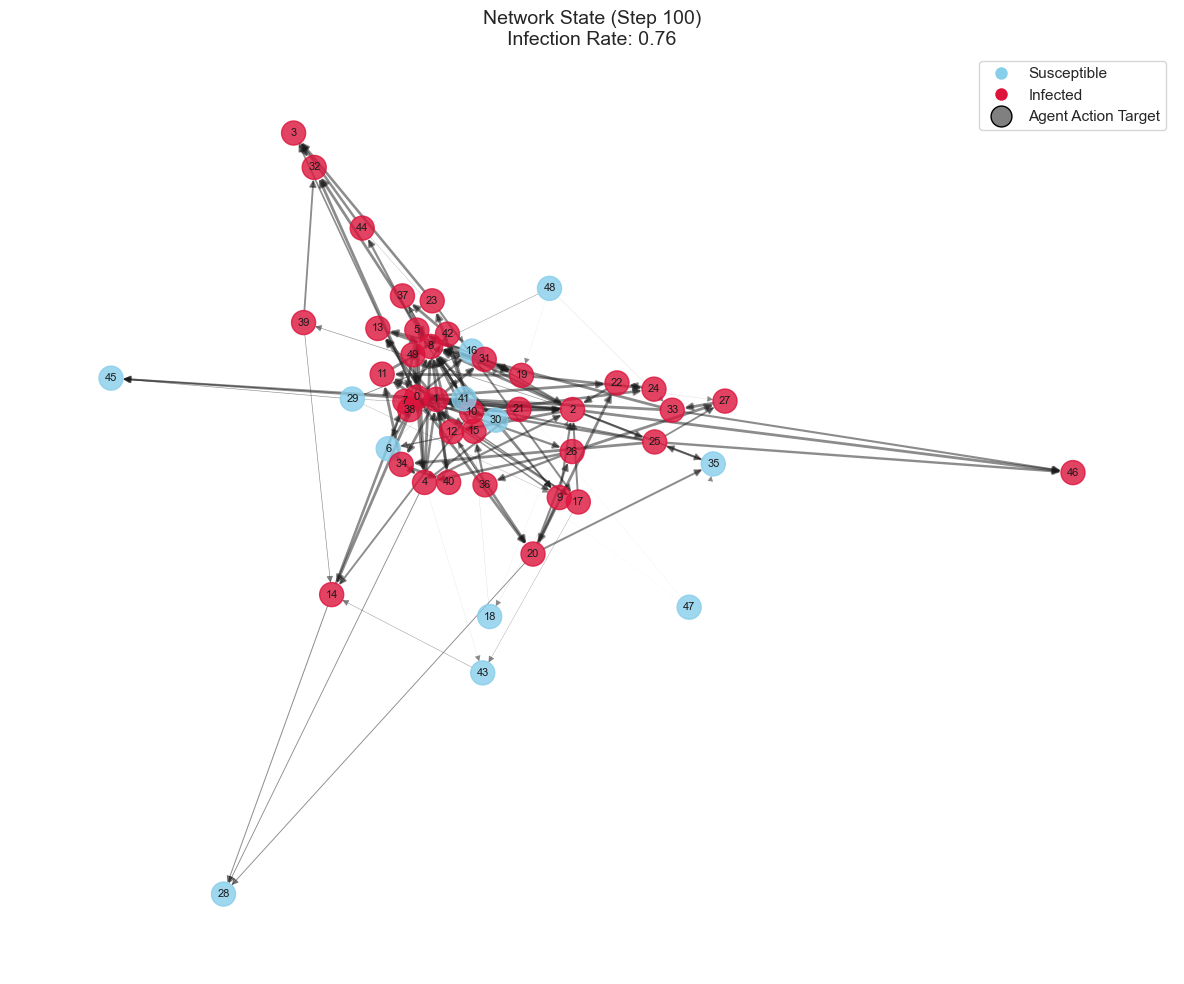

Episode finished after 100 steps
Final infection rate: 0.7600


In [22]:
# Run a random policy episode with visualization
random_episode_data = run_random_policy_episode(env, visualize=True, visualize_every=5)

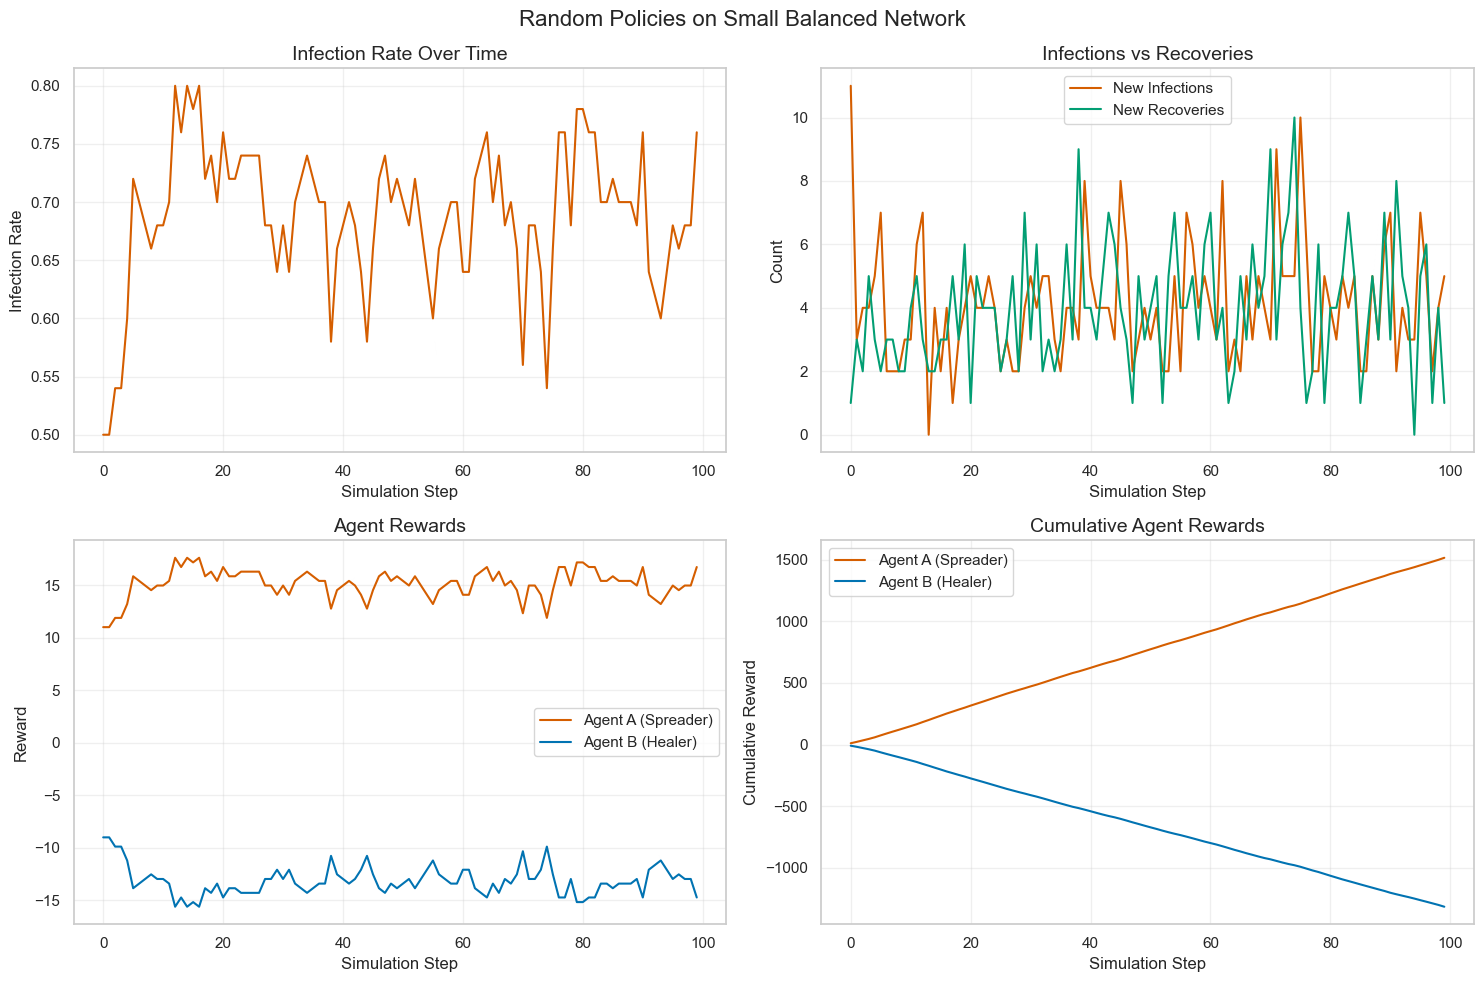

In [ ]:
def plot_episode_data(data, title="", filename = ""): 
# Plot the results of the random episode
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize="16", y=0.98) 

    # Plot 1: Infection Rate
    plt.subplot(2, 2, 1)
    plt.plot(data["infection_rates"], 'r-')
    plt.title("Infection Rate Over Time", fontsize=14)
    plt.xlabel("Simulation Step", fontsize=12)
    plt.ylabel("Infection Rate", fontsize=12)
    plt.grid(True, alpha=0.3)

    # Plot 2: New Infections vs New Recoveries
    plt.subplot(2, 2, 2)
    plt.plot(data["new_infections"], 'r-', label="New Infections")
    plt.plot(data["new_recoveries"], 'g-', label="New Recoveries")
    plt.title("Infections vs Recoveries", fontsize=14)
    plt.xlabel("Simulation Step", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Agent Rewards
    plt.subplot(2, 2, 3)
    plt.plot(data["rewards_a"], 'r-', label="Agent A (Spreader)")
    plt.plot(data["rewards_b"], 'b-', label="Agent B (Healer)")
    plt.title("Agent Rewards", fontsize=14)
    plt.xlabel("Simulation Step", fontsize=12)
    plt.ylabel("Reward", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Cumulative Rewards
    plt.subplot(2, 2, 4)
    plt.plot(np.cumsum(data["rewards_a"]), 'r-', label="Agent A (Spreader)")
    plt.plot(np.cumsum(data["rewards_b"]), 'b-', label="Agent B (Healer)")
    plt.title("Cumulative Agent Rewards", fontsize=14)
    plt.xlabel("Simulation Step", fontsize=12)
    plt.ylabel("Cumulative Reward", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{filename}.png"))
    plt.show()

plot_episode_data(random_episode_data, title="Random Policies on Viral Network Network", filename="random_policy_episode" )

## 2. Define Experiment Configurations

Next, let's define several configurations for training our agents.

In [10]:
# Define network size and node count
N_NODES = 100

# Configuration 1: Balanced Baseline
# This configuration has balanced parameters between Agent A and Agent B
balanced_config = NetworkEnvironmentConfig(
    desc="Balanced (scale free)", 
    network_type=NetworkType.SCALE_FREE,
    nx_n=N_NODES,
    nx_m=3,
    num_nodes=N_NODES,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.5,
    infection_probability=0.7,
    recovery_probability=0.15,
    max_steps=150,
    max_action_radius=1 
)

# Configuration 2: Small World Network
# This configuration models close-knit communities with high connectivity
small_world_config = NetworkEnvironmentConfig(
    desc="High connectivity (small world)",
    network_type=NetworkType.SMALL_WORLD,
    nx_n=N_NODES,
    nx_k=8,  # Higher connectivity
    nx_p=0.1,  # Low rewiring (more clustered)
    num_nodes=N_NODES,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.1,
    infection_probability=0.5,
    recovery_probability=0.2,
    max_steps=150,
    max_action_radius=1
)

# Configuration 3: Viral Spread
# Models scenarios where information spreads quickly but doesn't persist
viral_config = NetworkEnvironmentConfig(
    desc="Viral (scale free)",
    network_type=NetworkType.SCALE_FREE,
    nx_n=N_NODES,
    nx_m=4,  # Higher connectivity
    num_nodes=N_NODES,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.1,
    infection_probability=0.9,  # Very high infection rate
    recovery_probability=0.5,   # High recovery rate
    max_steps=120,
    max_action_radius=1
)

# Configuration 4: Random Network
random_config = NetworkEnvironmentConfig(
    desc="Random (erdos-renyi)",
    network_type=NetworkType.ERDOS_RENYI,
    nx_n=N_NODES,
    nx_p=0.1,  # Connection probability
    num_nodes=N_NODES,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.15,
    infection_probability=0.55,
    recovery_probability=0.25,
    max_steps=150,
    max_action_radius=1
)


# Configuration 5: Persistent Infection
# Models scenarios where information spreads slowly but is hard to eliminate
persistent_config = NetworkEnvironmentConfig(
    desc="Persistent (scale free)",
    network_type=NetworkType.SCALE_FREE,
    nx_n=N_NODES,
    nx_m=2,  # Lower connectivity
    num_nodes=N_NODES,
    num_features=FeatureRegistry.get_feature_count(),
    initial_infection_density=0.3,
    infection_probability=0.4,  # Lower infection rate
    recovery_probability=0.1,   # Very low recovery rate
    max_steps=200,              # Longer simulations
    max_action_radius=1
)

# Dictionary to easily access configurations by name
EXPERIMENT_CONFIGS = {
    "balanced": balanced_config,
    "small_world": small_world_config,
    "viral": viral_config,
    "random": random_config,
    "baseline": persistent_config,
}

## 3. Train Policies for Multiple Configurations

Now we'll train policies for each configuration using PPO.

In [11]:
# Constants for training
NUM_ITERATIONS = 100 
TRAIN_BATCH_SIZE = 4000

def algo_config_from_env(env_config): 
    """
        Small helper to generate config for the algorithm 
        from the environment config.
    """
    return (
    PPOConfig()
        .environment("network_spread", env_config=env_config.to_dict())
        .multi_agent(
            policies={
                "agent_a": PolicySpec(
                    observation_space=env_config.get_observation_space().get("agent_a"),
                    action_space=env_config.get_action_space().get("agent_a") 
                ),
                "agent_b": PolicySpec(
                    observation_space=env_config.get_observation_space().get("agent_b"),
                    action_space=env_config.get_action_space().get("agent_b") 
                )
            },
            policy_mapping_fn=lambda agent_id, *args, **kwargs: agent_id
        )
        .framework("torch")
        .training(
            train_batch_size=TRAIN_BATCH_SIZE,
            lr=5e-5,
            gamma=0.99,
            lambda_=0.95,
            entropy_coeff=0.2,
        )
        .rollouts(
            num_rollout_workers=2,
            rollout_fragment_length=100
        )
        .debugging(log_level="WARNING")
        .callbacks(InfoSpreadCallbacks)
        .reporting(
            keep_per_episode_custom_metrics=True,
        )
    )


In [12]:
def train_policy(config_name, env_config, num_iterations=NUM_ITERATIONS):
    """Train a policy using the specified configuration and save the results."""
    print(f"Starting training for configuration: {config_name}")
    
    # Set up the PPO configuration
    config = algo_config_from_env(env_config)
    
    # Initialize algorithm
    algo = config.build()
    
    # Storage for metrics
    metrics_history = {
        "infection_rate_mean": [],
        "avg_infection_duration_mean": [],
        "new_infections_mean": [],
        "new_recoveries_mean": [],
        "reward_agent_a": [],
        "reward_agent_b": []
    }
    
    # Initialize progress bar
    progress_bar = tqdm(total=num_iterations, desc=f"Training {config_name}")
    
    # Plot for live updates
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Training loop with metric collection and live visualization
    for i in range(num_iterations):
        result = algo.train()
        
        # Extract and store metrics
        for key in metrics_history:
            if key.startswith("reward"):
                agent = key.replace("reward_", "")
                if agent in result['policy_reward_mean']:
                    metrics_history[key].append(
                        result['policy_reward_mean'][agent]
                    )
                else:
                    metrics_history[key].append(0.0)
                    
            elif key in result['custom_metrics']:
                metrics_history[key].append(
                    result['custom_metrics'][key]
                )
            elif key in result.get('hist_stats', {}):
                # Some metrics might be in hist_stats instead
                metrics_history[key].append(np.mean(result['hist_stats'][key]))
            else:
                # If metric isn't found, add None to maintain consistency
                metrics_history[key].append(None)
                    
        # Update progress bar
        progress_bar.update(1)
        progress_bar.set_postfix({
            "infection_rate_mean": f"{float(metrics_history['infection_rate_mean'][-1]):.4f}" if metrics_history['infection_rate_mean'] and metrics_history['infection_rate_mean'][-1] is not None else "N/A",
            "reward_a": f"{float(metrics_history['reward_agent_a'][-1]):.4f}" if metrics_history['reward_agent_a'] and metrics_history['reward_agent_a'][-1] is not None else "N/A",
            "reward_b": f"{float(metrics_history['reward_agent_b'][-1]):.4f}" if metrics_history['reward_agent_b'] and metrics_history['reward_agent_b'][-1] is not None else "N/A"
        })
        
        # Live plot update every 5 iterations
        if i % 5 == 0 or i == num_iterations - 1:
            # Clear axes
            for ax in axes:
                ax.clear()
            
            # Plot agent rewards
            if metrics_history['infection_rate_mean']:
                valid_data = [x for x in metrics_history['infection_rate_mean'] if x is not None] 
                if valid_data:
                    axes[0].plot(valid_data, 'r-')
                    axes[0].set_title("Average Terminal Infection Rate over Training")
                    axes[0].set_xlabel("Training Iteration")
                    axes[0].set_ylabel("Rate")
                    axes[0].grid(True, alpha=0.3)    
                               
            if metrics_history['reward_agent_a'] and metrics_history['reward_agent_b']:
                valid_a = [x for x in metrics_history['reward_agent_a'] if x is not None]
                valid_b = [x for x in metrics_history['reward_agent_b'] if x is not None]
                if valid_a and valid_b:
                    axes[1].plot(valid_a, 'r-', label="Agent A (Spreader)")
                    axes[1].plot(valid_b, 'b-', label="Agent B (Healer)")
                    axes[1].set_title("Agent Rewards During Training")
                    axes[1].set_xlabel("Training Iteration")
                    axes[1].set_ylabel("Reward")
                    axes[1].legend()
                    axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            os.path.join(PLOTS_DIR, "random_policy_episode.png")
            fig_path = os.path.join(PLOTS_DIR, f"{config_name}_training_data.png")
            plt.savefig(fig_path)
            print(f"Progress plot saved to {fig_path}")
    
    progress_bar.clear()

    # Save the trained policies
    checkpoint_dir = os.path.join(CHECKPOINTS_DIR, f"{config_name}")
    checkpoint_path = algo.save(checkpoint_dir)
    print(f"Saved checkpoint to: {checkpoint_path}")
    
    # Save the metrics history
    metrics_df = pd.DataFrame(metrics_history)
    metrics_df.to_csv(os.path.join(RESULTS_DIR, f"{config_name}_metrics.csv"), index=False)
    
    # Return the trained algorithm and metrics for further analysis
    return algo, metrics_history

In [36]:
# Initialize Ray with the correct runtime environment
if ray.is_initialized():
    ray.shutdown()

# Create a runtime environment that includes the modules directory
runtime_env = {
    "env_vars": {"PYTHONPATH": f"{os.getcwd()}"}
}

# Initialize Ray with this environment
ray.init(runtime_env=runtime_env)

# Register the environment with Ray
register_env("network_spread", env_creator)


2025-04-30 19:49:42,419	INFO worker.py:1752 -- Started a local Ray instance.


In [ ]:

# Train models for each configuration
trained_algos = {}
metrics_history_for_config = {}

# Select configurations to train
# For efficiency we only choose 3 configurations
policies_to_train = ["balanced", "small_world", "viral"]

for policy_name in policies_to_train:
    env_config = EXPERIMENT_CONFIGS[policy_name]
    algo, metrics = train_policy(policy_name, env_config)
    trained_algos[policy_name] = algo
    metrics_history_for_config[policy_name] = metrics
    
    # Save metrics to CSV
    metrics_df = pd.DataFrame(metrics)
    metrics_df.to_csv(os.path.join(RESULTS_DIR, f"{policy_name}_metrics.csv"), index=False)
    print(f"Saved metrics for {policy_name} to {os.path.join(RESULTS_DIR, f'{policy_name}_metrics.csv')}")

In [61]:
import pandas as pd
import glob
import ast

def load_training_metrics(policy_name, results_dir=RESULTS_DIR):
    """Quick load of RLlib metrics from CSV."""
    # Find the progress.csv file
    csv_file = glob.glob(f"{results_dir}/**/{policy_name}_metrics.csv", recursive=True)[0]
    
    # Load the data
    df = pd.read_csv(csv_file)
    print(df)
    # Extract custom metrics (columns starting with 'custom_metrics/')
        
    return df.to_dict(orient='list')

# If we lost our live data, reload it 
# so we don't have to re-run training every time. 
print(policies_to_train)

# if "metrics_history_for_config" not in locals() and "metrics_history_for_config" not in globals() or not metrics_history_for_config:
metrics_history_for_config = {policy_name: load_training_metrics(policy_name) for policy_name in policies_to_train}
prettyprint(metrics_history_for_config)

['balanced', 'small_world', 'viral']
    infection_rate_mean  avg_infection_duration_mean  new_infections_mean  \
0              0.531923                          0.0             3.038462   
1              0.296346                          0.0             1.634615   
2              0.198500                          0.0             1.062500   
3              0.097200                          0.0             0.440000   
4              0.025100                          0.0             0.040000   
..                  ...                          ...                  ...   
95             0.014600                          0.0             0.000000   
96             0.014500                          0.0             0.000000   
97             0.014500                          0.0             0.000000   
98             0.013000                          0.0             0.000000   
99             0.013500                          0.0             0.000000   

    new_recoveries_mean  reward_agent_

dict_keys(['balanced', 'small_world', 'viral'])
Creating comparison plots...


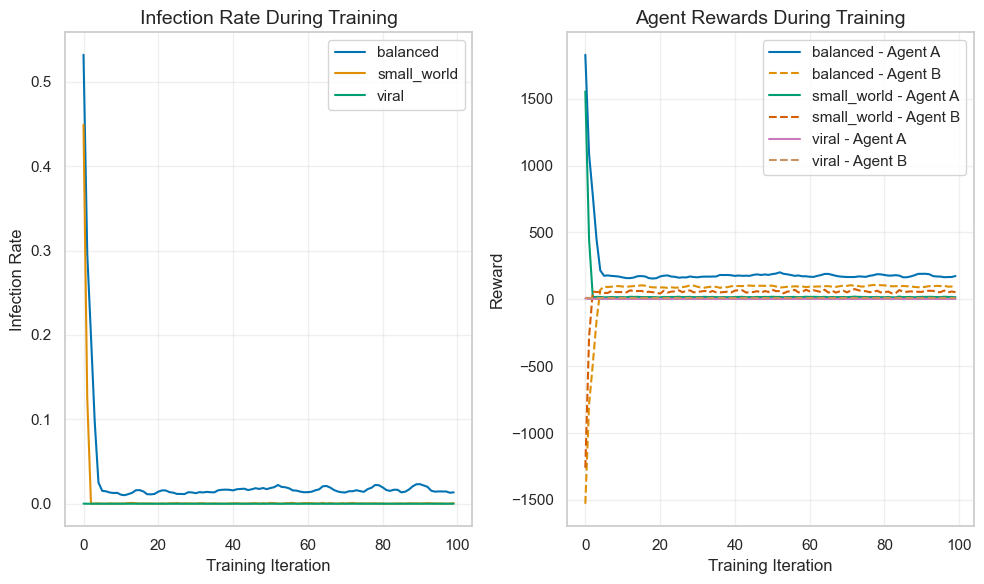

Comparison plot saved to /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/plots/training_comparison.png


In [62]:
# Create comparison plots if we have metrics
print(metrics_history_for_config.keys())
if metrics_history_for_config:
    print("Creating comparison plots...")
    
    # Set up the Seaborn style
    sns.set(style="whitegrid", context="notebook", palette="colorblind")
    
    # Create a figure for the plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    
    # Plot 1: Infection Rate Comparison
    ax1 = axes[0]
    for config_name, metrics in metrics_history_for_config.items():
        if "infection_rate_mean" in metrics and metrics["infection_rate_mean"]:
            valid_data = [x for x in metrics["infection_rate_mean"] if x is not None]
            if valid_data:
                ax1.plot(valid_data, label=config_name)
    ax1.set_title("Infection Rate During Training", fontsize=14)
    ax1.set_xlabel("Training Iteration", fontsize=12)
    ax1.set_ylabel("Infection Rate", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Agent Rewards Comparison
    ax2 = axes[1]
    for config_name, metrics in metrics_history_for_config.items():
        if "reward_agent_a" in metrics and metrics["reward_agent_a"]:
            valid_data = [x for x in metrics["reward_agent_a"] if x is not None]
            if valid_data:
                ax2.plot(valid_data, linestyle='-', 
                         label=f"{config_name} - Agent A")
        if "reward_agent_b" in metrics and metrics["reward_agent_b"]:
            valid_data = [x for x in metrics["reward_agent_b"] if x is not None]
            if valid_data:
                ax2.plot(valid_data, linestyle='--', 
                         label=f"{config_name} - Agent B")
    ax2.set_title("Agent Rewards During Training", fontsize=14)
    ax2.set_xlabel("Training Iteration", fontsize=12)
    ax2.set_ylabel("Reward", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "training_comparison.png"))
    plt.show()    
    print(f"Comparison plot saved to {os.path.join(PLOTS_DIR, 'training_comparison.png')}")

## 4. Analyze Trained Policies

In [ ]:
# Analysis of Agent B's Action Choices

def analyze_agent_b_behavior(policy_name, env_config, num_episodes=5, policy_algo=None):
    """Analyze how Agent B chooses actions after training."""
    print(f"Analyzing Agent B behavior for {policy_name}...")
    
    # Try to load the trained policy
    try:
        # Check if checkpoint exists
        algo = policy_algo
        if policy_algo is None: 
            checkpoint_dir = os.path.join(CHECKPOINTS_DIR, policy_name)
            if not os.path.exists(checkpoint_dir):
                print(f"No checkpoint found for {policy_name}. Skipping analysis.")
                return None
                    
            # Restore from checkpoint
            algo = Algorithm.from_checkpoint(checkpoint_dir)
            # print(f"Loaded checkpoint from {checkpoint_dir}")
            
        # Create environment for evaluation
        env = MultiAgentNetworkEnv(env_config)
        
        # Track Agent B action choices
        action_data = {
            "node_selections": [],  # Track which nodes Agent B selects
            "radius_choices": [],   # Track radius choices
            "node_states": [],      # Was the node infected or susceptible?
            "node_degrees": [],     # Node degree in network
            "node_influence": [],   # Node influence (centrality)
            "local_infection_rate": [],  # Infection rate in neighborhood
            "infection_pressure": [], 
            "length_of_infection": [], 
            "internal_influence": []
        }   

        # Initialize array to track infection rates across episodes and steps
        infection_rates = np.zeros((num_episodes, env_config.max_steps))
        infection_rates.fill(np.nan)  # Fill with NaN to handle variable episode lengths

        # Run episodes
        for episode in range(num_episodes):
            obs, _ = env.reset()
            done = {"__all__": False}
            step = 0
            
            while not done["__all__"] and step < env.max_steps:
                # Record infection rate for this step
                infection_rates[episode, step] = env.current_infection_rate
                
                # Get actions from policies
                actions = {}
                
                for agent_id in obs:
                    action = algo.compute_single_action(obs[agent_id], policy_id=agent_id)
                    
                    # Convert to format expected by environment
                    if agent_id == "agent_a":
                        actions[agent_id] = action
                    else:  # agent_b
                        node_id = action['node_id']
                        radius = action['radius']
                        actions[agent_id] = {"node_id": node_id, "radius": radius}
                        
                        # Save Agent B action data
                        action_data["node_selections"].append(node_id)
                        action_data["radius_choices"].append(radius)
                        
                        # Get node state
                        node_state = 1 if env.network.nodes[node_id]["state"] == NodeState.INFECTED else 0
                        action_data["node_states"].append(node_state)
                        
                        # Get node degree
                        node_degree = env.network.degree(node_id)
                        action_data["node_degrees"].append(node_degree)
                        
                        node_data = FeatureRegistry.extract_all_features(env.network)
                    
                        # Get node infection pressure 
                        action_data['infection_pressure'].append(node_data[NodeFeatures.INFECTION_PRESSURE.name].get(node_id, 0))

                        # Get node length of infection 
                        action_data['length_of_infection'].append(node_data[NodeFeatures.LENGTH_OF_INFECTION.name].get(node_id, 0))

                        # Get node internal influence 
                        action_data['internal_influence'].append(node_data[NodeFeatures.INTERNAL_INFLUENCE.name].get(node_id, 0))
                        
                        # Get local infection rate (in neighborhood)
                        neighbors = list(env.network.neighbors(node_id))
                        if neighbors:
                            local_infected = sum(1 for n in neighbors if env.network.nodes[n]["state"] == NodeState.INFECTED)
                            local_rate = local_infected / len(neighbors)
                        else:
                            local_rate = 0
                        action_data["local_infection_rate"].append(local_rate)
                
                # Take step
                obs, rewards, terminateds, truncateds, infos = env.step(actions)
                done = terminateds
                step += 1
            
            # print(f"Completed episode {episode+1}/{num_episodes}")
        
        # Create analysis plots
        # Plot 0: Infection Trajectory
        plt.figure(figsize=(30, 12))

        # Calculate mean and percentiles across episodes for each step
        mean_rates = np.nanmedian(infection_rates, axis=1)
        p25 = np.nanpercentile(infection_rates, 25, axis=1)
        p75 = np.nanpercentile(infection_rates, 75, axis=1)
        
        # Plot mean with fill between for 25-75 percentile range
        steps = np.arange(len(mean_rates))
        plt.plot(steps, mean_rates, label=policy_name)
        plt.fill_between(steps, p25, p75, alpha=0.3)
        plt.title(f"{policy_name}: Infection Rate Trajectory")
        plt.xlabel("Step")
        plt.ylabel("Infection Rate")
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, f"{policy_name}_infection_rate_trajectories.png"))
        plt.show()

        # Create multi-panel figure for agent behavior analysis
        plt.figure(figsize=(20, 16))
        plt.suptitle(f"{policy_name}: Agent B Behavior Analysis", fontsize=18, y=0.98)
        
        # Plot 1: Radius choice distribution
        plt.subplot(2, 4, 1)
        radius_counts = np.bincount(action_data["radius_choices"], minlength=env_config.max_action_radius+1)
        radius_labels = [f"Radius {i}" for i in range(len(radius_counts))]
        sns.barplot(x=radius_labels, y=radius_counts)
        plt.title("Radius Choices", fontsize=14)
        plt.ylabel("Count", fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Node state vs radius choice
        plt.subplot(2, 4, 2)
        df = pd.DataFrame({
            "Node State": ["Infected" if s == 1 else "Susceptible" for s in action_data["node_states"]],
            "Radius": action_data["radius_choices"]
        })
        state_radius_counts = df.groupby(["Node State", "Radius"]).size().reset_index(name="Count")
        pivot_data = state_radius_counts.pivot(index="Node State", columns="Radius", values="Count").fillna(0)
        sns.heatmap(pivot_data, annot=True, fmt="g", cmap="YlGnBu")
        plt.title("Node State vs Radius Choice", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Node State", fontsize=12)
        
        # Plot 3: Node degree vs agent choice
        plt.subplot(2, 4, 3)
        df = pd.DataFrame({
            "Degree": action_data["node_degrees"],
            "Was Chosen": np.ones(len(action_data["node_degrees"]))
        })
        degree_bins = [0, 2, 4, 6, 8, 10, 15, 20, 30, 100]
        df["Degree Bin"] = pd.cut(df["Degree"], bins=degree_bins)
        degree_counts = df.groupby("Degree Bin")["Was Chosen"].sum().reset_index()
        plt.bar(degree_counts["Degree Bin"].astype(str), degree_counts["Was Chosen"])
        plt.title("Node Degree Distribution", fontsize=14)
        plt.xlabel("Node Degree", fontsize=12)
        plt.ylabel("Times Selected", fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

        # Plot 4: Node degree vs radius choice - FIXED from 'node_degree' to 'node_degrees'
        plt.subplot(2, 4, 4)
        df = pd.DataFrame({
            "Degree": action_data["node_degrees"],
            "Radius": action_data["radius_choices"]
        })
        sns.boxplot(x="Radius", y="Degree", data=df)
        plt.title("Degree vs Radius Choice", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Degree", fontsize=12)
        plt.grid(True, alpha=0.3)  
        
        # Plot 5: Local infection rate vs radius
        plt.subplot(2, 4, 5)
        df = pd.DataFrame({
            "Local Infection Rate": action_data["local_infection_rate"],
            "Radius": action_data["radius_choices"]
        })
        sns.boxplot(x="Radius", y="Local Infection Rate", data=df)
        plt.title("Local Infection Rate vs Radius", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Local Infection Rate", fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Plot 6: Infection pressure vs radius 
        plt.subplot(2, 4, 6)
        df = pd.DataFrame({
            "Infection Pressure": action_data["infection_pressure"],
            "Radius": action_data["radius_choices"]
        })
        sns.boxplot(x="Radius", y="Infection Pressure", data=df)
        plt.title("Infection Pressure vs Radius", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Infection Pressure", fontsize=12)
        plt.grid(True, alpha=0.3)

        # Plot 7: Internal influence vs radius
        plt.subplot(2, 4, 7)
        df = pd.DataFrame({
            "Internal Influence": action_data["internal_influence"],
            "Radius": action_data["radius_choices"]
        })
        sns.boxplot(x="Radius", y="Internal Influence", data=df)
        plt.title("Internal Influence vs Radius", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Internal Influence", fontsize=12)
        plt.grid(True, alpha=0.3)        
                
        # Plot 8: Length of infection vs radius - FIXED typo in 'Lenfth of Infection'
        plt.subplot(2, 4, 8)
        df = pd.DataFrame({
            "Length of Infection": action_data["length_of_infection"],
            "Radius": action_data["radius_choices"]
        })
        # Use boxplot instead of bar graph for consistency
        sns.boxplot(x="Radius", y="Length of Infection", data=df)
        plt.title("Length of Infection vs Radius", fontsize=14)
        plt.xlabel("Radius", fontsize=12)
        plt.ylabel("Length of Infection", fontsize=12)
        plt.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle
        plt.savefig(os.path.join(PLOTS_DIR, f"{policy_name}_agent_b_analysis.png"))
        plt.show()

        print(f"Agent B analysis for {policy_name} saved to {os.path.join(PLOTS_DIR, f'{policy_name}_agent_b_analysis.png')}")
        
        return action_data
        
    except Exception as e:
        print(f"Error analyzing Agent B behavior for {policy_name}: {e}")
        import traceback
        traceback.print_exc()
        return None


print("\nAnalyzing Agent B behavior...")
agent_b_data = {}

for policy_name, env_config in EXPERIMENT_CONFIGS.items():
    agent_b_data[policy_name] = analyze_agent_b_behavior(policy_name, env_config, num_episodes=100)


Analyzing network structure effects...


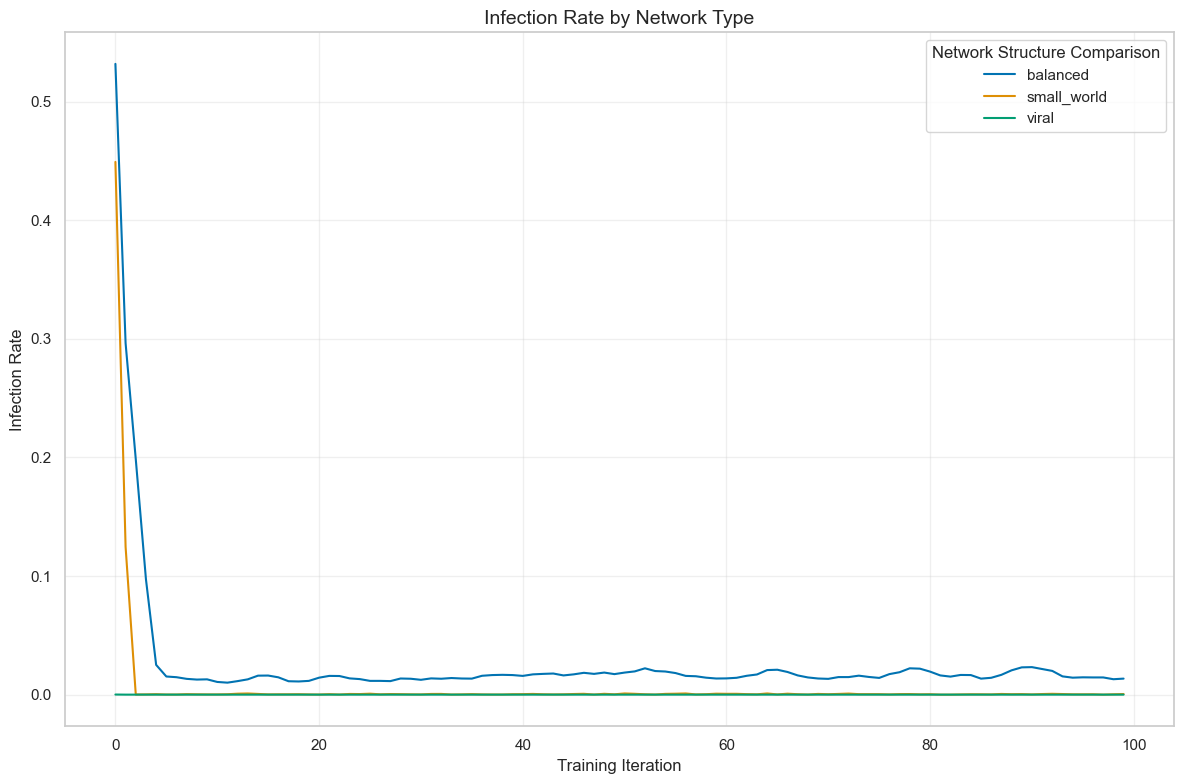

Network structure analysis saved to /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/plots/network_structure_effects.png


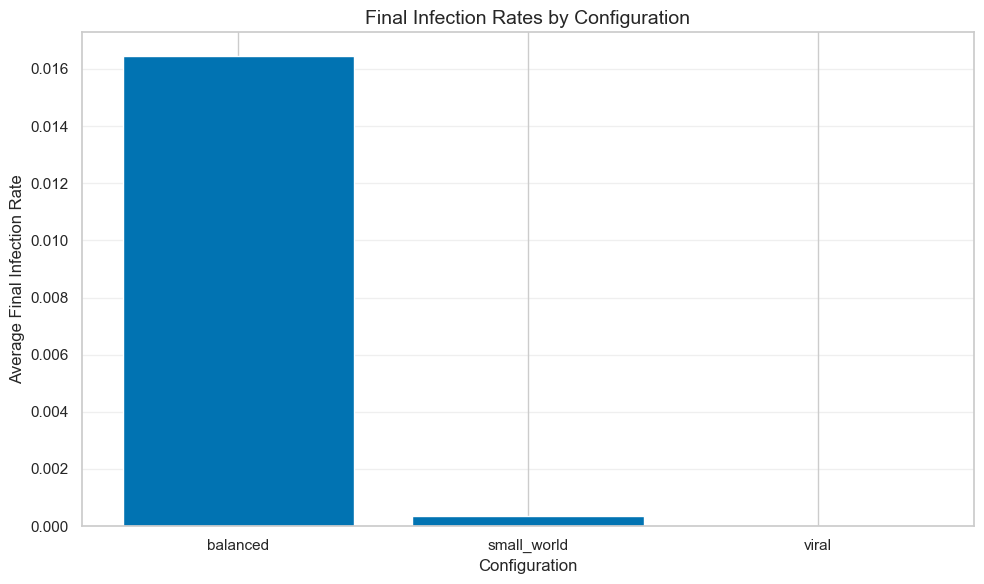

Final infection rates analysis saved to /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/plots/final_infection_rates.png


In [165]:
# Network Structure Analysis
def analyze_network_structure_effects(metrics_history_for_config):
    """Compare how different network structures affect infection spread."""

    print("\nAnalyzing network structure effects...")
    
    # Create a DataFrame for easier plotting
    network_data = []
    
    for config_name, metrics in metrics_history_for_config.items():
        if "infection_rate_mean" in metrics and metrics["infection_rate_mean"]:
            network_type = EXPERIMENT_CONFIGS[config_name].network_type
            
            for i, rate in enumerate(metrics["infection_rate_mean"]):
                if rate is not None:  # Skip None values
                    network_data.append({
                        "Configuration": config_name,
                        "Network Type": network_type,
                        "Iteration": i,
                        "Infection Rate": rate
                    })
    
    if not network_data:
        print("No infection rate data available for analysis.")
        return
        
    df = pd.DataFrame(network_data)
    
    # Create plot
    plt.figure(figsize=(12, 8))
    
    # Line plot with confidence intervals
    sns.lineplot(x="Iteration", y="Infection Rate", hue="Configuration", data=df)
    
    plt.title("Infection Rate by Network Type", fontsize=14)
    plt.xlabel("Training Iteration", fontsize=12)
    plt.ylabel("Infection Rate", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Network Structure Comparison")
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "network_structure_effects.png"))
    plt.show()
    
    print(f"Network structure analysis saved to {os.path.join(PLOTS_DIR, 'network_structure_effects.png')}")
    
    # Additional analysis - final infection rates
    plt.figure(figsize=(10, 6))
    
    # Get the average of the last 10 iterations for each configuration
    final_rates = {}
    for config_name, metrics in metrics_history_for_config.items():
        if "infection_rate_mean" in metrics and len(metrics["infection_rate_mean"]) >= 10:
            valid_rates = [r for r in metrics["infection_rate_mean"][-10:] if r is not None]
            if valid_rates:
                final_rates[config_name] = np.mean(valid_rates)
    
    if final_rates:
        plt.bar(final_rates.keys(), final_rates.values())
        plt.title("Final Infection Rates by Configuration", fontsize=14)
        plt.xlabel("Configuration", fontsize=12)
        plt.ylabel("Average Final Infection Rate", fontsize=12)
        plt.grid(True, alpha=0.3, axis='y')
            
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "final_infection_rates.png"))
        plt.show()
        
        print(f"Final infection rates analysis saved to {os.path.join(PLOTS_DIR, 'final_infection_rates.png')}")

# Run network structure analysis if we have metrics
if metrics_history_for_config:   
        analyze_network_structure_effects(metrics_history_for_config)

## 5. Run Parameter Sweep 

In [15]:
def run_policy_episode(policy_name, env, visualize=True, visualize_every=1, policy_algo=None):
    """
        Run an episode with trained policy (according to config_name)
    """

    # Check if checkpoint exists
    algo = policy_algo 
    if policy_algo is None:
        checkpoint_dir = os.path.join(CHECKPOINTS_DIR, policy_name)
        if not os.path.exists(checkpoint_dir):
            print(f"No checkpoint found for {config_name}. Skipping analysis.")
            return None      
        # Restore from checkpoint
        algo = Algorithm.from_checkpoint(checkpoint_dir)
        print(f"Loaded checkpoint from {checkpoint_dir}")
    
    # Reset environment
    obs, _ = env.reset()
    done = {"__all__": False}
    
    # Data for analysis
    step = 1
    infection_rates = []
    new_infections = []
    new_recoveries = []
    rewards_a = []
    rewards_b = []
    
    # Run episode
    while not done["__all__"] and step <= env.max_steps:
        # Compute Action
        # Check observation shape compatibility
        train_shape = algo.get_policy("agent_a").model.obs_space.shape
        current_shape = obs["agent_a"].shape
        if train_shape != current_shape:
            print(f"Warning: Shape mismatch. Model expects {train_shape}, got {current_shape}")
            # Here you could resize the observation or use a different policy
        agent_a_action = algo.compute_single_action(obs["agent_a"], policy_id="agent_a")
        agent_b_action = algo.compute_single_action(obs["agent_b"], policy_id="agent_b")
        
        actions = {
            "agent_a": agent_a_action,
            "agent_b": agent_b_action
        }
        
        # Take step
        obs, rewards, terminateds, truncateds, infos = env.step(actions)
        done = terminateds
        
        # Record data
        infection_rate = env.current_infection_rate
        infection_rates.append(infection_rate)
        new_infections.append(len(env.newly_infected_nodes))
        new_recoveries.append(len(env.newly_recovered_nodes))
        rewards_a.append(rewards["agent_a"])
        rewards_b.append(rewards["agent_b"])
        
        # Visualize if requested
        if visualize and step % visualize_every == 0:
            clear_output(wait=True)
            visualize_network_state(env.network, step, infection_rate, 
                                   agent_a_action["node_id"], agent_b_action)
            # Print statistics
            print(f"Step {step}:")
            print(f"  Infection Rate: {infection_rate:.4f}")
            print(f"  New Infections: {len(env.newly_infected_nodes)}")
            print(f"  New Recoveries: {len(env.newly_recovered_nodes)}")
            print(f"  Agent A Reward: {rewards['agent_a']:.4f}")
            print(f"  Agent B Reward: {rewards['agent_b']:.4f}")
            time.sleep(0.5)  # Pause to see visualization
        
        step += 1
    
    # Final visualization
    if visualize:
        clear_output(wait=True)
        visualize_network_state(env.network, step, env.current_infection_rate)
        print(f"Episode finished after {step} steps")
        print(f"Final infection rate: {env.current_infection_rate:.4f}")
    
    # Return data for analysis
    return {
        "infection_rates": infection_rates,
        "new_infections": new_infections,
        "new_recoveries": new_recoveries,
        "rewards_a": rewards_a,
        "rewards_b": rewards_b,
        "steps": step
    }

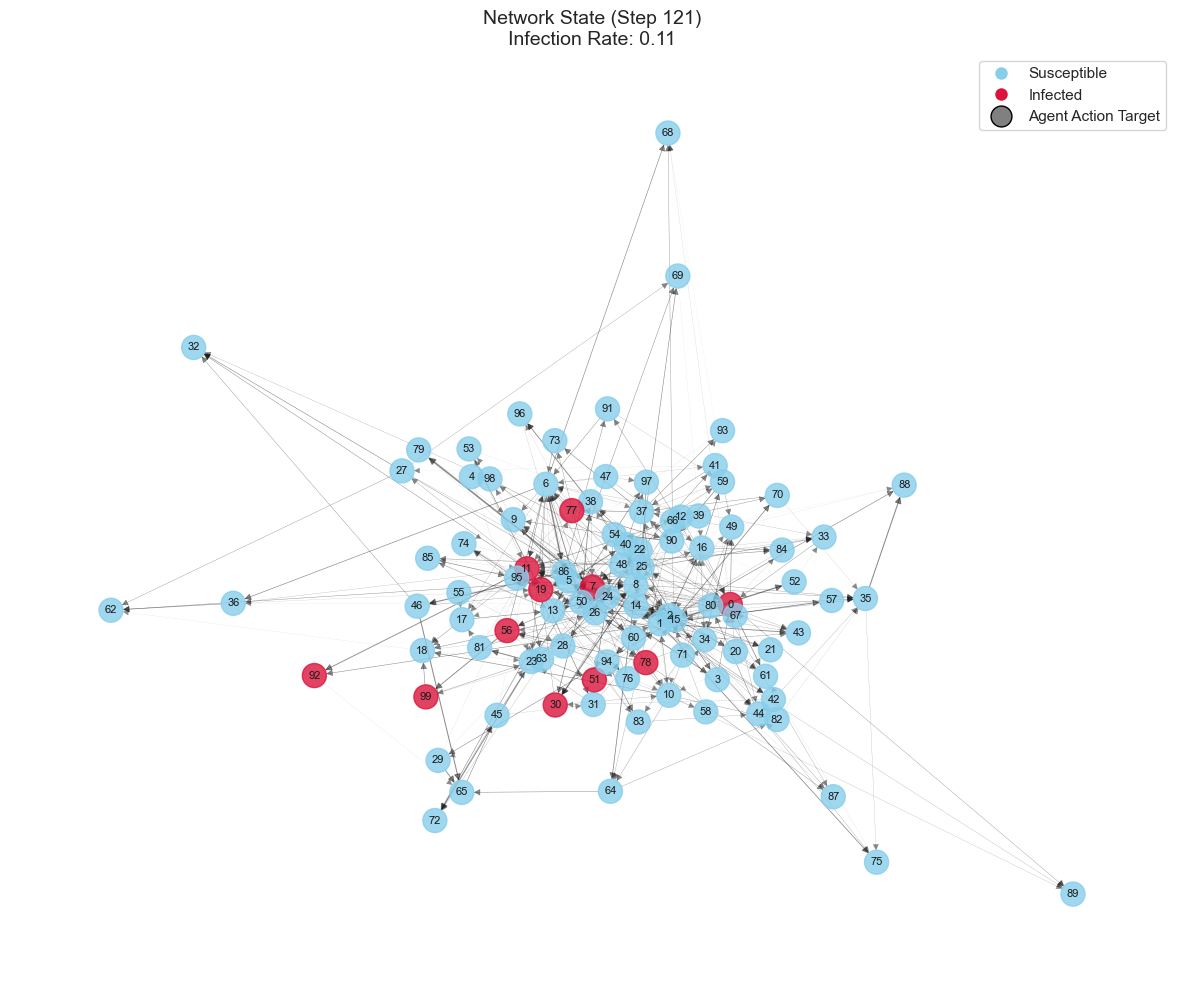

Episode finished after 121 steps
Final infection rate: 0.1100


In [167]:
# Visualize trained agents playing against each other

policy_episode_data = run_policy_episode("viral", MultiAgentNetworkEnv(EXPERIMENT_CONFIGS['viral']))

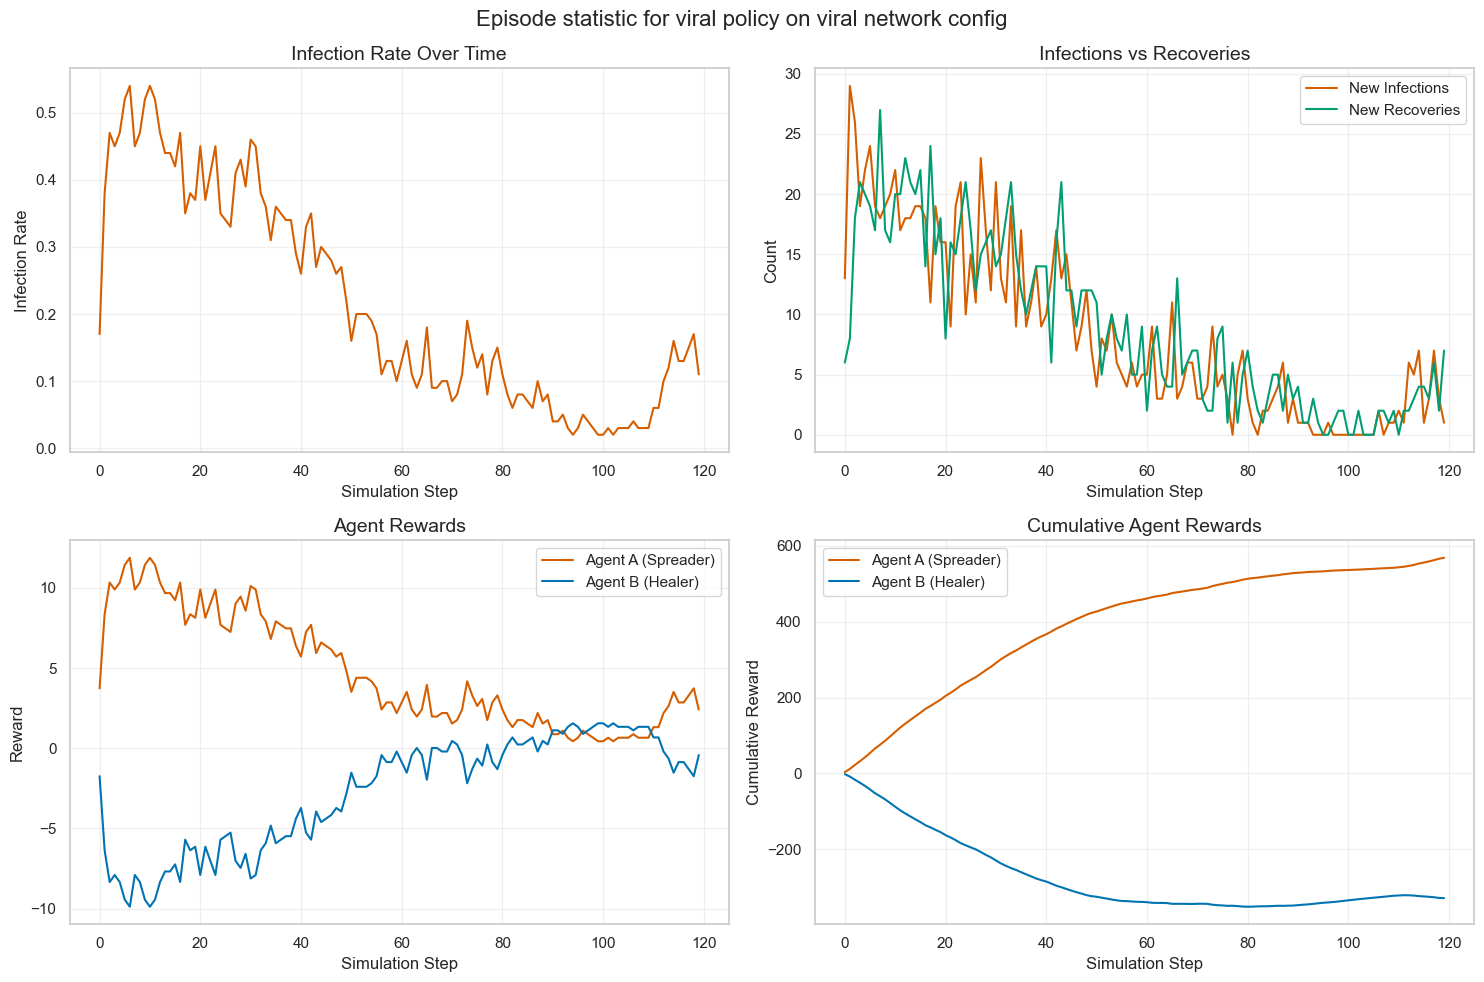

In [168]:
plot_episode_data(policy_episode_data, title="Episode statistic for viral policy on viral network config" ,filename="viral_policy_episode_statistics")

In [ ]:
# Parameter Sweep Experiment
policies_to_sweep = ["balanced", "small_world", "viral"]
def run_parameter_sweep(policy_name, env_config):
    """Run a parameter sweep to analyze the effect of different parameters."""
    if policy_name not in policies_to_sweep:
        raise ValueError(f"Not trained policy for configruations {policy_name}")
    
    config_name = env_config.get_safe_desc() # Get rid of whitespace in the name.
    checkpoint_dir = os.path.join(CHECKPOINTS_DIR, policy_name)
    if not os.path.exists(checkpoint_dir):
        print(f"No checkpoint found for {policy_name}. Skipping sweep.")
        return None  
             
    # Restore from checkpoint
    algo = Algorithm.from_checkpoint(checkpoint_dir)

    # print(f"Loaded {policy_name} checkpoint from {checkpoint_dir}")
    
    # Load environment config
    print("\nSetting up parameter sweep experiment...")
    
    # Parameters to sweep
    # TODO Upgrade to LHS
    infection_probs = [ 0.2, 0.3, 0.5, 0.7, 0.8]
    recovery_probs = [0.05, 0.1, 0.15, 0.3, 0.4, 0.5]
    initial_infection_densities = [0.3, 0.5, 0.7]
    
    # Base configuration (use balanced as template)
    base_config = env_config
    
    # Ask for user confirmation
    print(f"This will run {len(infection_probs) * len(recovery_probs) * len(initial_infection_densities)} configurations.")

    # Storage for results
    sweep_results = []
    counter = 0
    # Run the sweep
    for inf_prob in infection_probs:
        for rec_prob in recovery_probs:
            for initial_density in initial_infection_densities:
                counter +=1 
                print("="*50)
                print(f'Sweeping for configuration {counter}/{len(infection_probs) * len(recovery_probs) * len(initial_infection_densities)}')
                print("="*50)
                # sweep_params_str = f"sweep_inf{inf_prob}_rec{rec_prob}_den{initial_density}"
                # print(f"\nRunning configuration: {sweep_params_str}")
                
                # Create new config with these parameters
                sweep_config = NetworkEnvironmentConfig(
                    network_type=base_config.network_type,
                    nx_n=base_config.nx_n,
                    nx_m=base_config.nx_m,
                    num_nodes=base_config.num_nodes,
                    num_features=base_config.num_features,
                    initial_infection_density=initial_density,
                    infection_probability=inf_prob,
                    recovery_probability=rec_prob,
                    max_steps=base_config.max_steps,
                    max_action_radius=base_config.max_action_radius
                )
                
                # Create environment for evaluation
                env = MultiAgentNetworkEnv(sweep_config)
                
                
                # Run random policy episodes
                num_episodes = 5
                episode_results = []
                
                for episode in range(num_episodes):
                    results = run_policy_episode(policy_name, env, visualize=False)
                    episode_results.append({
                        "final_infection_rate": results["infection_rates"][-1] if results["infection_rates"] else 0,
                        "avg_infection_rate": np.mean(results["infection_rates"]) if results["infection_rates"] else 0,
                        "steps": results["steps"],
                        "total_agent_a_reward": sum(results["rewards_a"]),
                        "total_agent_b_reward": sum(results["rewards_b"])
                    })
                    print(f"Completed episode {episode+1}/{num_episodes}")
                
                # Calculate averages
                avg_results = {
                    "infection_prob": inf_prob,
                    "recovery_prob": rec_prob,
                    "initial_density": initial_density,
                    "final_infection_rate": np.mean([ep["final_infection_rate"] for ep in episode_results]),
                    "avg_infection_rate": np.mean([ep["avg_infection_rate"] for ep in episode_results]),
                    "avg_steps": np.mean([ep["steps"] for ep in episode_results]),
                    "avg_agent_a_reward": np.mean([ep["total_agent_a_reward"] for ep in episode_results]),
                    "avg_agent_b_reward": np.mean([ep["total_agent_b_reward"] for ep in episode_results])
                }
                
                sweep_results.append(avg_results)
            print(f"Configuration {config_name} complete. Average infection rate: {avg_results['avg_infection_rate']:.4f}")
    
    # Convert to DataFrame for analysis
    sweep_df = pd.DataFrame(sweep_results)
    
    # Save results
    sweep_df.to_csv(os.path.join(RESULTS_DIR, f"{policy_name}-{config_name}_parameter_sweep_results.csv"), index=False)
    print(f"\nParameter sweep results saved to {os.path.join(RESULTS_DIR, f'{policy_name}-{config_name}_parameter_sweep_results.csv')}")
    
    return sweep_df

In [17]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

def create_enhanced_parameter_sweep_visualizations(sweep_df, policy_name, config_name):
    """
    Create enhanced visualizations for parameter sweep results including:
    1. A 3D surface plot
    2. The original scatterplot
    
    Parameters:
    -----------
    sweep_df : pandas.DataFrame
        DataFrame containing parameter sweep results
    policy_name : str
        Name of the policy used
    config_name : str
        Name of the environment configuration
    save_path : str
        Path to save the visualization
    """
    # Extract unique values for each parameter
    infection_probs = sorted(sweep_df['infection_prob'].unique())
    recovery_probs = sorted(sweep_df['recovery_prob'].unique())
    
    # Create a figure with 2 subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Create 3D surface plot
    ax1 = fig.add_subplot(2, 1, 1, projection='3d')
    
    # For each initial density, create a separate surface plot
    initial_densities = sorted(sweep_df['initial_density'].unique())
    
    # Choose a specific density to visualize (you can modify this)
    selected_density = initial_densities[2]  # using the third density
    
    # Filter data for the selected density
    filtered_df = sweep_df[sweep_df['initial_density'] == selected_density]
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(infection_probs, recovery_probs)
    Z = np.zeros((len(recovery_probs), len(infection_probs)))
    
    # Fill the Z matrix with average infection rates
    for i, rec_prob in enumerate(recovery_probs):
        for j, inf_prob in enumerate(infection_probs):
            data_point = filtered_df[(filtered_df['infection_prob'] == inf_prob) & 
                                     (filtered_df['recovery_prob'] == rec_prob)]
            if not data_point.empty:
                Z[i, j] = data_point['avg_infection_rate'].values[0]
    
    # Create the surface plot
    surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, 
                          linewidth=0, antialiased=True, alpha=0.8)
    
    # Add a color bar
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='Average Infection Rate')
    
    # Set labels and title
    ax1.set_xlabel('Infection Probability')
    ax1.set_ylabel('Recovery Probability')
    ax1.set_zlabel('Average Infection Rate')
    ax1.set_title(f'3D Surface Plot for Initial Density = {selected_density}\n'
                 f'Policy: {policy_name}, Config: {config_name}')
    
    # 2. Create scatterplot (original visualization)
    ax2 = fig.add_subplot(2, 1, 2)
    scatter = sns.scatterplot(
        data=sweep_df,
        x="infection_prob",
        y="recovery_prob",
        hue="avg_infection_rate",
        size="avg_infection_rate",
        sizes=(20, 200),
        palette="viridis",
        ax=ax2
    )
    
    # Improve the legend
    norm = plt.Normalize(sweep_df['avg_infection_rate'].min(), sweep_df['avg_infection_rate'].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    
    # Add a colorbar to the scatterplot
    cbar = ax2.figure.colorbar(sm, ax=ax2)
    cbar.set_label("Average Infection Rate", rotation=270, labelpad=20)
    
    # Remove the original legend which can be cluttered
    ax2.legend_.remove()
    
    ax2.set_title(f"Parameter Sweep Scatterplot\nPolicy: {policy_name}, Config: {config_name}")
    ax2.set_xlabel("Infection Probability")
    ax2.set_ylabel("Recovery Probability")
    
    # Add annotation about multiple densities if applicable
    if len(initial_densities) > 1:
        ax2.annotate(f"Note: Scatterplot shows all initial densities: {initial_densities}",
                   xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'{policy_name}-{config_name}_param_sweep.png'))
    plt.show()
    
    # Create additional plots for different initial densities if needed
    if len(initial_densities) > 1:
        # Create a figure with multiple 3D plots for different densities
        fig = plt.figure(figsize=(18, 12))
        
        for i, density in enumerate(initial_densities):
            # Calculate subplot position
            rows = int(np.ceil(len(initial_densities) / 2))
            ax = fig.add_subplot(rows, 2, i+1, projection='3d')
            
            # Filter data for this density
            density_df = sweep_df[sweep_df['initial_density'] == density]
            
            # Create Z matrix for this density
            Z_density = np.zeros((len(recovery_probs), len(infection_probs)))
            
            for i_rec, rec_prob in enumerate(recovery_probs):
                for j_inf, inf_prob in enumerate(infection_probs):
                    data_point = density_df[(density_df['infection_prob'] == inf_prob) & 
                                         (density_df['recovery_prob'] == rec_prob)]
                    if not data_point.empty:
                        Z_density[i_rec, j_inf] = data_point['avg_infection_rate'].values[0]
            
            # Create the surface plot
            surf = ax.plot_surface(X, Y, Z_density, cmap=cm.viridis, 
                                 linewidth=0, antialiased=True, alpha=0.8)
            
            # Set labels and title
            ax.set_xlabel('Infection Probability')
            ax.set_ylabel('Recovery Probability')
            ax.set_zlabel('Average Infection Rate')
            ax.set_title(f'Initial Density = {density}')
        
        plt.suptitle(f'3D Surface Plots for All Initial Densities\n'
                   f'Policy: {policy_name}, Config: {config_name}', fontsize=16)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.savefig(os.path.join(PLOTS_DIR, f'{policy_name}-{config_name}_all_densities.png'))
        plt.show()

# Example of how to call this function:
# create_enhanced_parameter_sweep_visualizations(
#     sweep_df, 
#     policy_name, 
#     config_name, 
# )

2025-04-30 17:59:05,133	WARNING util.py:62 -- Install gputil for GPU system monitoring.


Loaded viral checkpoint from /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/checkpoints/viral

Setting up parameter sweep experiment...
This will run 90 configurations.
Sweeping for configuration 1/90


2025-04-30 17:59:08,004	WARNING util.py:62 -- Install gputil for GPU system monitoring.


Loaded checkpoint from /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/checkpoints/viral
Completed episode 1/5


2025-04-30 17:59:11,926	WARNING util.py:62 -- Install gputil for GPU system monitoring.


...

Loaded checkpoint from /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/checkpoints/viral
Completed episode 3/5


2025-04-30 18:27:37,702	WARNING util.py:62 -- Install gputil for GPU system monitoring.


Loaded checkpoint from /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/checkpoints/viral
Completed episode 4/5


2025-04-30 18:27:40,836	WARNING util.py:62 -- Install gputil for GPU system monitoring.


Loaded checkpoint from /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/checkpoints/viral
Completed episode 5/5
Configuration Viral(scalefree) complete. Average infection rate: 0.1069

Parameter sweep results saved to /Users/UM/Documents/UM25/Complex/RL Project/modules/experiment_results/viral-Viral(scalefree)_parameter_sweep_results.csv


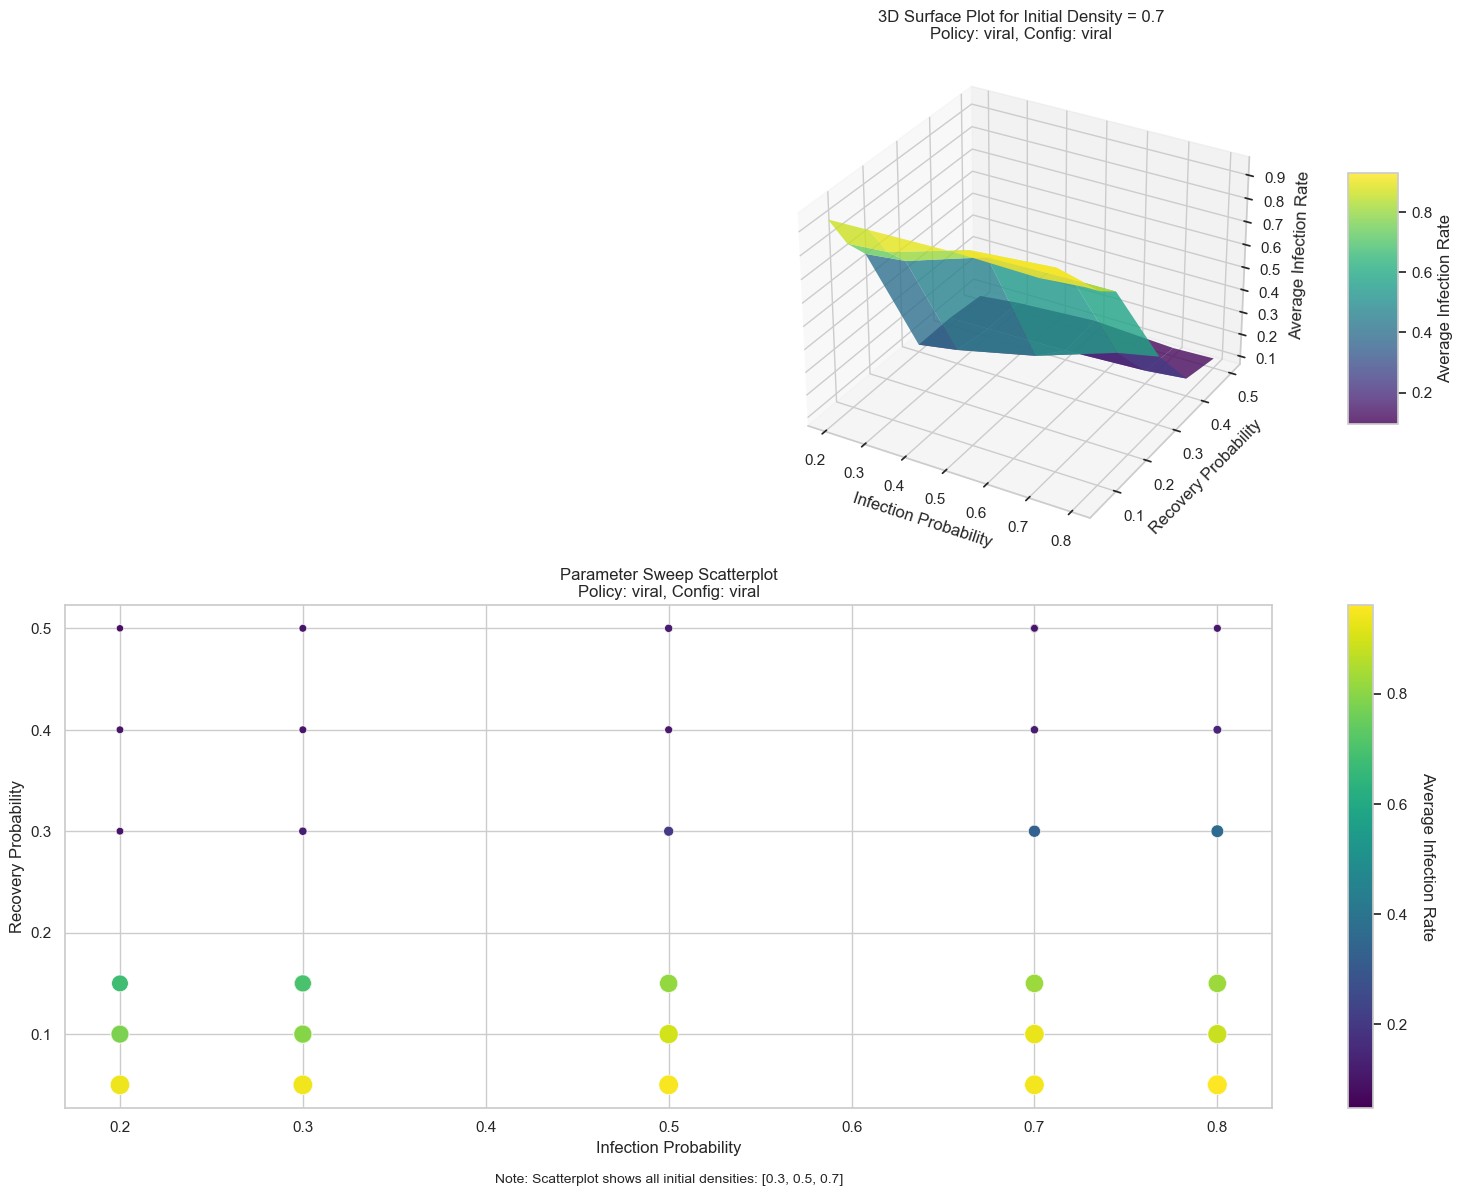

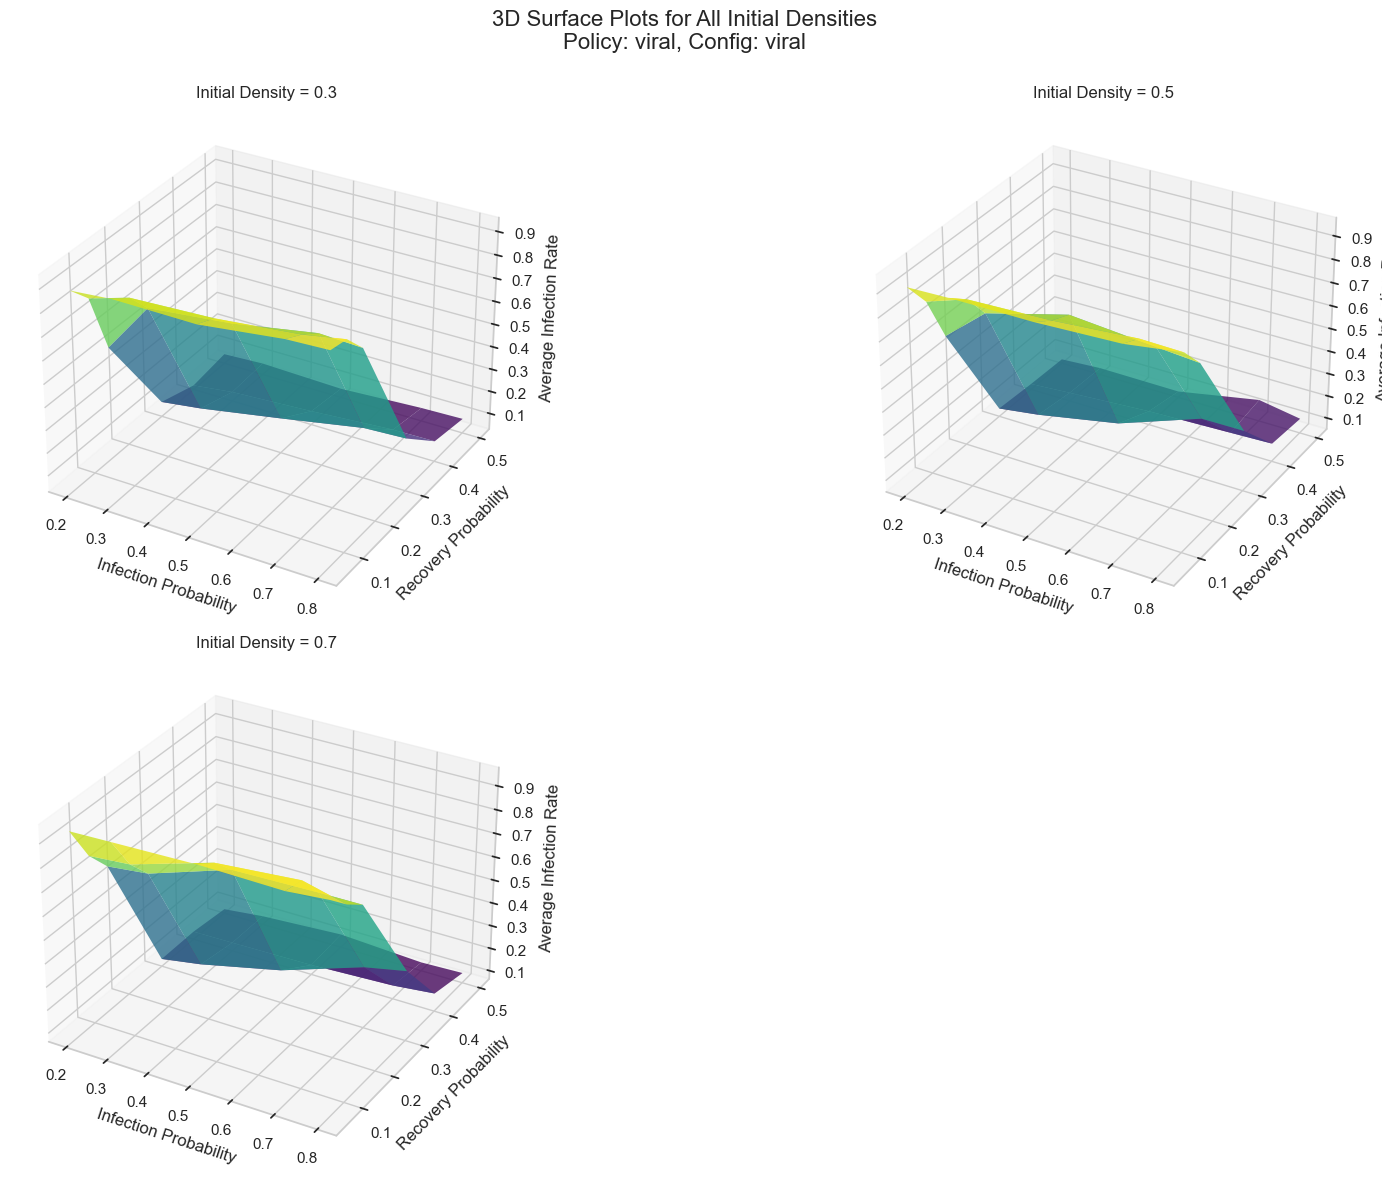

In [20]:
# Debugging
sweep_df = run_parameter_sweep('viral',EXPERIMENT_CONFIGS['viral'])
create_enhanced_parameter_sweep_visualizations(sweep_df, 'viral', 'viral')
# for policy_name in policies_to_sweep: 
#     for env_name, env_config in EXPERIMENT_CONFIGS.items():

        # try:
        #     run_parameter_sweep(policy_name, env_config)

        # except: 
        #     nl = "\n"
        #     print(f"""
        #             Error in parameter sweep for config: {nl}
        #             {env_config.to_dict()}{nl}{nl}
        #             with policy {policy_name}
        #           """)
        

In [ ]:
# Run this the first time you open this notebook
%pip install ipywidgets plotly

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

def create_interactive_parameter_sweep_widget(sweep_df=None):
    """
    Creates an interactive widget for visualizing parameter sweep results
    
    Parameters:
    -----------
    sweep_df : pandas.DataFrame
        DataFrame containing parameter sweep results. If None, sample data will be generated.
    """
    # Generate sample data if none provided
    if sweep_df is None:
        # Parameters to sweep
        infection_probs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        recovery_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
        initial_infection_densities = [0.1, 0.3, 0.5, 0.7]
        
        # Storage for results
        sweep_results = []
        
        # Generate synthetic data
        for inf_prob in infection_probs:
            for rec_prob in recovery_probs:
                for initial_density in initial_infection_densities:
                    # Simple model: higher infection prob and initial density increase infection rate
                    # higher recovery prob decreases infection rate
                    avg_infection_rate = (0.7 * inf_prob + 0.3 * initial_density - 0.5 * rec_prob)
                    avg_infection_rate = max(0.05, min(0.95, avg_infection_rate + np.random.normal(0, 0.05)))
                    
                    avg_results = {
                        "infection_prob": inf_prob,
                        "recovery_prob": rec_prob,
                        "initial_density": initial_density,
                        "avg_infection_rate": avg_infection_rate,
                        "final_infection_rate": avg_infection_rate * (1 + np.random.normal(0, 0.1)),
                        "avg_steps": 50 + 100 * avg_infection_rate + np.random.normal(0, 10),
                        "avg_agent_a_reward": -100 * avg_infection_rate + np.random.normal(0, 10),
                        "avg_agent_b_reward": 100 * avg_infection_rate + np.random.normal(0, 10)
                    }
                    
                    sweep_results.append(avg_results)
        
        sweep_df = pd.DataFrame(sweep_results)
    
    # Get unique values
    initial_densities = sorted(sweep_df['initial_density'].unique())
    infection_probs = sorted(sweep_df['infection_prob'].unique())
    recovery_probs = sorted(sweep_df['recovery_prob'].unique())
    
    # Create the widget layout
    style = {'description_width': 'initial'}
    density_dropdown = widgets.Dropdown(
        options=[(f'Initial Density: {d}', d) for d in initial_densities],
        value=initial_densities[0],
        description='Choose Initial Infection Density:',
        style=style,
        layout=widgets.Layout(width='50%')
    )
    
    plot_type_tabs = widgets.Tab()
    plot_type_tabs.children = [widgets.Output(), widgets.Output()]
    plot_type_tabs.set_title(0, '3D Surface Plot')
    plot_type_tabs.set_title(1, 'Scatter Plot')
    
    color_dropdown = widgets.Dropdown(
        options=['Viridis', 'Plasma', 'Inferno', 'Magma', 'Cividis'],
        value='Viridis',
        description='Color Scale:',
        style=style,
        layout=widgets.Layout(width='40%')
    )
    
    z_value_dropdown = widgets.Dropdown(
        options=['avg_infection_rate', 'final_infection_rate', 'avg_steps', 
                'avg_agent_a_reward', 'avg_agent_b_reward'],
        value='avg_infection_rate',
        description='Measured Value:',
        style=style,
        layout=widgets.Layout(width='50%')
    )
    
    # Create main widget
    main_widget = widgets.VBox([
        widgets.HBox([density_dropdown, z_value_dropdown, color_dropdown]),
        plot_type_tabs
    ])
    
    # Function to update the plots
    def update_plots(density, z_value, colorscale):
        # Filter data for the selected density
        filtered_df = sweep_df[sweep_df['initial_density'] == density]
        
        # Clear outputs
        plot_type_tabs.children[0].clear_output()
        plot_type_tabs.children[1].clear_output()
        
        # Create a grid for the surface plot
        x_mesh, y_mesh = np.meshgrid(infection_probs, recovery_probs)
        z_mesh = np.zeros((len(recovery_probs), len(infection_probs)))
        
        # Fill the Z matrix with values
        for i, rec_prob in enumerate(recovery_probs):
            for j, inf_prob in enumerate(infection_probs):
                data_point = filtered_df[(filtered_df['infection_prob'] == inf_prob) & 
                                        (filtered_df['recovery_prob'] == rec_prob)]
                if not data_point.empty:
                    z_mesh[i, j] = data_point[z_value].values[0]
        
        # Display 3D Surface Plot
        with plot_type_tabs.children[0]:
            fig_3d = go.Figure(data=[go.Surface(
                z=z_mesh, 
                x=x_mesh, 
                y=y_mesh,
                colorscale=colorscale.lower()
            )])
            
            fig_3d.update_layout(
                title=f'3D Surface Plot for Initial Density = {density}',
                scene=dict(
                    xaxis_title='Infection Probability',
                    yaxis_title='Recovery Probability',
                    zaxis_title=z_value.replace('_', ' ').title(),
                    xaxis=dict(tickmode='array', tickvals=infection_probs),
                    yaxis=dict(tickmode='array', tickvals=recovery_probs)
                ),
                autosize=True,
                height=600,
                margin=dict(l=0, r=0, b=0, t=40)
            )
            
            display(fig_3d)
        
        # Display Scatter Plot
        with plot_type_tabs.children[1]:
            fig_scatter = go.Figure()
            
            # Add a scatter trace for each density value if all densities should be shown
            for d in [density]:  # Can be changed to initial_densities to show all
                density_df = sweep_df[sweep_df['initial_density'] == d]
                
                fig_scatter.add_trace(go.Scatter(
                    x=density_df['infection_prob'],
                    y=density_df['recovery_prob'],
                    mode='markers',
                    marker=dict(
                        size=density_df[z_value] * 50,  # Scale marker sizes
                        color=density_df[z_value],
                        colorscale=colorscale.lower(),
                        colorbar=dict(title=z_value.replace('_', ' ').title()),
                        showscale=True
                    ),
                    text=[f'Infection Prob: {row.infection_prob}<br>'
                          f'Recovery Prob: {row.recovery_prob}<br>'
                          f'{z_value.replace("_", " ").title()}: {getattr(row, z_value):.4f}'
                          for _, row in density_df.iterrows()],
                    hoverinfo='text',
                    name=f'Density: {d}'
                ))
            
            fig_scatter.update_layout(
                title=f'Parameter Sweep Scatter Plot for Initial Density = {density}',
                xaxis_title='Infection Probability',
                yaxis_title='Recovery Probability',
                autosize=True,
                height=600,
                hovermode='closest'
            )
            
            display(fig_scatter)
    
    # Connect the widget controls to the update function
    widgets.interactive_output(
        update_plots, 
        {'density': density_dropdown, 'z_value': z_value_dropdown, 'colorscale': color_dropdown}
    )
    
    # Initialize the plots
    update_plots(initial_densities[0], 'avg_infection_rate', 'Viridis')
    
    return main_widget

# To use with your actual parameter sweep results:
def display_3d_widget(sweep_df):
    """
    Integrates the interactive widget with your parameter sweep function
    
    Parameters:
    -----------
    policy_name : str
        Name of the policy used
    env_config : object
        Environment configuration object
    sweep_df : pandas.DataFrame
        DataFrame with parameter sweep results
    """    
    # Create and display the widget with your actual data
    widget = display_3d_widget(sweep_df)
    display(widget)
        
    return widget


In [28]:
# Interactive Widget
integrate_with_parameter_sweep(sweep_df)

In [ ]:
# Final summary
print("\n" + "="*50)
print("Network Spread Experiments Complete!")
print("="*50)
print(f"All results saved to: {RESULTS_DIR}")
print(f"Plots saved to: {PLOTS_DIR}")
print(f"Model checkpoints saved to: {CHECKPOINTS_DIR}")

# Cleanup 
if ray.is_initialized():
    ray.shutdown()